# Multi-Output Gaussian Process: Training and Evaluation

This notebook implements the training and evaluation pipeline for the Multi-Output Gaussian Process (MOGP) model using the processed features extracted in the previous step.

**Objectives:**
1.  **Load Processed Data:** Import the extracted topological features and targets.
2.  **Define Model:** Initialize the Variational Gaussian Process (GP) with Linear Model of Coregionalization (LMC).
3.  **Train:** Optimize the model using the Evidence Lower Bound (ELBO) loss function.
4.  **Evaluate:** Assess performance on classification (Spectral Overlap) and regression (OSNR) tasks.

## 1. Setup and Imports
We initialize the environment by setting random seeds for reproducibility and selecting the appropriate compute device (CPU/GPU). We also import the necessary PyTorch and GPyTorch libraries, alongside standard data manipulation tools.

In [ ]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
def load_dataset(data_path="processed_data", test_size=0.2, seed=42):
    """
    Load processed dataset from .npy files.

    Args:
        data_path (str): Path to directory containing .npy files.
        test_size (float): Fraction of data to use for testing.
        seed (int): Random seed.

    Returns:
        train_x, train_y, test_x, test_y, scaler_x, scaler_y_osnr
    """
    path = Path(data_path)

    print(f"Loading data from {path}...")
    try:
        X = np.load(path / "X_features.npy")
        Y = np.load(path / "Y_targets.npy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Could not find data files in {path}. Ensure X_features.npy and Y_targets.npy exist."
        ) from e

    print(f"Loaded X: {X.shape}, Y: {Y.shape}")

    # Targets Processing
    # Column 0: Spacing (Continuous) -> Overlap (Binary)
    # Threshold: <= 35.2 is Overlap (1), > 35.2 is No Overlap (0)
    BANDWIDTH = 32  # GHz
    ROLLOFF_FACTOR = 0.1
    spacing = Y[:, 0]
    y_overlap = (spacing <= BANDWIDTH * (1 + ROLLOFF_FACTOR)).astype(float)

    # Column 1: OSNR (Continuous)
    y_osnr = Y[:, 1]

    # Stack targets: [Overlap, OSNR]
    # Task 0: Overlap (Binary)
    # Task 1: OSNR (Continuous)
    y = np.stack([y_overlap, y_osnr], axis=1)

    # Split
    # Stratify by overlap to maintain class distribution
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y_overlap
    )

    # Normalize Inputs
    scaler_x = StandardScaler()
    X_train = scaler_x.fit_transform(X_train)
    X_test = scaler_x.transform(X_test)

    # Normalize OSNR (Target 1)
    # We don't normalize Binary target (Target 0)
    scaler_y_osnr = StandardScaler()
    y_train_osnr = scaler_y_osnr.fit_transform(y_train[:, 1].reshape(-1, 1)).flatten()
    y_test_osnr = scaler_y_osnr.transform(y_test[:, 1].reshape(-1, 1)).flatten()

    # Reassemble y
    y_train[:, 1] = y_train_osnr
    y_test[:, 1] = y_test_osnr

    # Convert to Tensor
    train_x = torch.tensor(X_train).float()
    train_y = torch.tensor(y_train).float()
    test_x = torch.tensor(X_test).float()
    test_y = torch.tensor(y_test).float()

    return train_x, train_y, test_x, test_y, scaler_x, scaler_y_osnr


### Detailed Architecture Components

#### 1. ApproximateGP (Sparse Variational GP)
We inherit from `gpytorch.models.ApproximateGP` because exact Gaussian Process inference scales cubically with the number of data points $O(N^3)$. For our dataset size (and potential scalability to millions of points), this is intractable.

**Solution: Inducing Points**
We introduce a set of $M$ **inducing points** $\mathbf{Z}$ (where $M \ll N$). These are learned locations that summarize the training data. The model learns a variational distribution $q(\mathbf{u})$ over the function values at these points, approximating the true posterior $p(\mathbf{u}|\mathbf{y})$.

**Objective**: This turns the problem into an optimization of the **Variational ELBO**, reducing complexity to $O(M^3)$ or even $O(NM^2)$.

#### 2. CholeskyVariationalDistribution
Inside the model, we define the form of the variational posterior distribution $q(\mathbf{u}) = \mathcal{N}(\mathbf{m}, \mathbf{S})$.

**Why Cholesky?**
To ensure the covariance matrix $\mathbf{S}$ is always **positive definite** (a requirement for multivariate Gaussians), we do not learn $\mathbf{S}$ directly. Instead, we learn a lower-triangular matrix $\mathbf{L}$ such that:
$$ \mathbf{S} = \mathbf{L}\mathbf{L}^\top $$
This is known as the **Cholesky Decomposition**. It provides:
*   **Numerical Stability**: Guaranteed positive definiteness.
*   **Efficiency**: Computations with triangular matrices are faster.

This distribution handles the uncertainty of our latent function values at the inducing points.

#### 3. Mathematical Reference
For a deeper dive into Variational Inference and Gaussian Processes, we refer to:
> **Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.**
> *Chapter 6: Kernel Methods* (for GP foundations)
> *Chapter 10: Approximate Inference* (for Variational reasoning)


In [ ]:
class MixedGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points, num_latents=3, num_tasks=2):
        """
        Multi-output GP using Linear Model of Coregionalization (LMC).

        Args:
            inducing_points: Inducing point locations (M x D)
            num_latents: Number of latent functions (default: 3)
            num_tasks: Number of output tasks (default: 2)
        """
        # Variational distribution for latent functions
        # We use Cholesky Variational Distribution to have a full covariance matrix in the
        # multivariate normal distribution
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0), batch_shape=torch.Size([num_latents])
        )

        # Base variational strategy
        base_variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        # LMC variational strategy - models task correlations
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            base_variational_strategy,
            num_tasks=num_tasks,
            num_latents=num_latents,
            latent_dim=-1,
        )

        super().__init__(variational_strategy)

        # Mean and covariance for latent functions
        self.mean_module = gpytorch.means.ConstantMean(
            batch_shape=torch.Size([num_latents])
        )

        # Composite Kernel: RBF + Matern + Periodic
        # Uses teacher suggestion for kernel
        self.covar_module = (
            gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel(batch_shape=torch.Size([num_latents])),
                batch_shape=torch.Size([num_latents]),
            )
            + gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.MaternKernel(
                    nu=2.5, batch_shape=torch.Size([num_latents])
                ),
                batch_shape=torch.Size([num_latents]),
            )
            + gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.PeriodicKernel(batch_shape=torch.Size([num_latents])),
                batch_shape=torch.Size([num_latents]),
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


In [2]:
SEED = 42
# Set random seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Load Data
We load the extracted topological feature vectors and their corresponding targets. The features were pre-computed in the previous notebook (`01_ProbabilisticFeatures.ipynb`) and cached as `.npy` files to speed up experimentation.

*   **Task 0 (Classification):** Channel Overlap (Binary). Derived from channel bandwidth.
*   **Task 1 (Regression):** OSNR (Continuous).

In [ ]:
print("Loading dataset...")
train_x, train_y, test_x, test_y, scaler_x, scaler_y = load_dataset(
    data_path="processed_data"
)

print(f"Train X shape: {train_x.shape}")
print(f"Train Y shape: {train_y.shape}")
print(f"Test X shape:  {test_x.shape}")
print(f"Test Y shape:  {test_y.shape}")

# Move to device
train_x = train_x.to(device)
train_y = train_y.to(device)
test_x = test_x.to(device)
test_y = test_y.to(device)

Loading dataset...
Loading data from processed_data...
Loaded X: (5006, 20), Y: (5006, 2)
Train X shape: torch.Size([4004, 20])
Train Y shape: torch.Size([4004, 2])
Test X shape:  torch.Size([1002, 20])
Test Y shape:  torch.Size([1002, 2])


## 3. Model Definition
We define a multi-output Gaussian Process using the GPyTorch framework. To handle the mixed nature of our targets (Binary Overlap and Continuous OSNR) and ensure scalability, we employ a **Sparse Variational** strategy with a **Linear Model of Coregionalization (LMC)**.

### Mathematical Context: Linear Model of Coregionalization (LMC)
To model the correlation between the binary task (Overlap) and the continuous task (OSNR), we use the **LMC** framework. It expresses each output function $f_j(x)$ as a linear combination of a set of independent latent Gaussian Processes $u_q(x)$:
$$f_j(x) = \sum_{q=1}^{Q} a_{j,q} u_q(x)$$
Where:
* $Q$ is the number of latent functions (here $Q=3$).
* $a_{j,q}$ are the mixing coefficients learned during training.
* $u_q(x)$ are independent GPs with their own kernels.

This allows the model to learn shared structure (common features affecting both overlap and OSNR) while maintaining task-specific flexibility.


In [ ]:
# Hyperparameters
num_latents = 3

# Inducing Points
# Use inducing points (Sparse Approximation).
num_inducing = 1200

# Handle insufficient inducing points
if train_x.size(0) < num_inducing:
    num_inducing = train_x.size(0)

# Pick random samples for sparse approximation
inducing_idx = torch.randperm(train_x.size(0))[:num_inducing]
inducing_points = train_x[inducing_idx].clone()

print(f"Using {num_inducing} inducing points...")

# Model (check source for details)
model = MixedGPModel(inducing_points, num_latents=num_latents, num_tasks=2).to(device)

# Likelihoods
# Task 0: Spectral Overlap -> Bernoulli
# Task 1: OSNR -> Gaussian
likelihood = gpytorch.likelihoods.LikelihoodList(
    gpytorch.likelihoods.BernoulliLikelihood(),
    gpytorch.likelihoods.GaussianLikelihood(),
).to(device)

Using 1200 inducing points...


## 4. Training Loop
We train the model by optimizing the hyperparameters (kernel lengthscales, variational means, mixing weights).

### Mathematical Context: Variational ELBO
Since exact inference is intractable for non-Gaussian likelihoods (Bernoulli) and large datasets, we maximize the **Evidence Lower Bound (ELBO)**:
$$\mathcal{L}(q) = \sum_{i=1}^{N} \mathbb{E}_{q(f)} [\log p(y_i | f_i)] - \text{KL}(q(\mathbf{u}) || p(\mathbf{u}))$$
This objective balances:
1.  **Likelihood**: How well the model explains the data (OSNR regression error + Overlap classification accuracy).
2.  **KL Divergence**: Regularization term penalizing deviation of the variational posterior from the prior.


Starting training...


  0%|          | 0/50 [00:00<?, ?it/s]

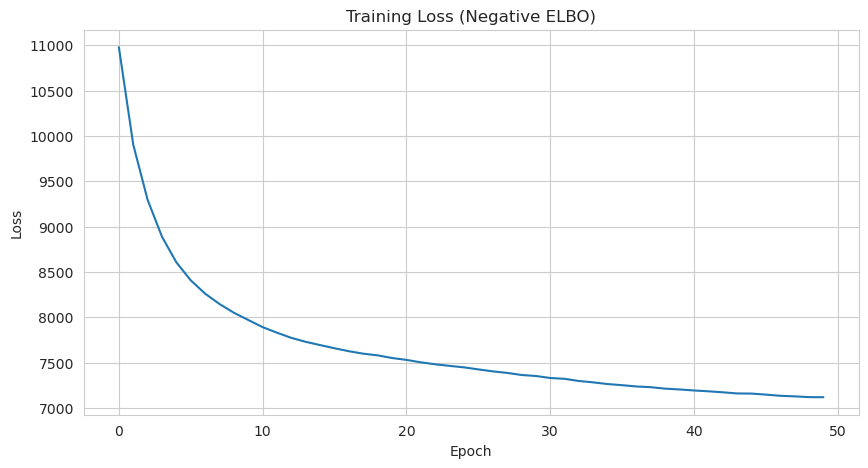

In [ ]:
# Training Config
epochs = 50
batch_size = 1024
# Learning rate for Adam optimizer
lr = 0.01

optimizer = torch.optim.Adam(
    [
        {"params": model.parameters()},
        {"params": likelihood.parameters()},
    ],
    lr=lr,
)

train_dataset = TensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model.train()
likelihood.train()

loss_history = []

print("Starting training...")
pbar = tqdm(range(epochs))

for epoch in pbar:
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        output = model(batch_x)

        # Separate distributions
        mean = output.mean
        var = output.variance
        dist_overlap = gpytorch.distributions.MultivariateNormal(
            mean[:, 0], torch.diag_embed(var[:, 0])
        )
        dist_osnr = gpytorch.distributions.MultivariateNormal(
            mean[:, 1], torch.diag_embed(var[:, 1])
        )

        # Calculate Loss (Negative ELBO)
        log_prob_overlap = (
            likelihood.likelihoods[0]
            .expected_log_prob(batch_y[:, 0], dist_overlap)
            .sum()
        )
        log_prob_osnr = (
            likelihood.likelihoods[1].expected_log_prob(batch_y[:, 1], dist_osnr).sum()
        )
        kl_div = model.variational_strategy.kl_divergence().sum()

        scale = train_x.size(0) / batch_x.size(0)
        loss = -(scale * (log_prob_overlap + log_prob_osnr) - kl_div)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    pbar.set_postfix({"loss": avg_loss})

plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Training Loss (Negative ELBO)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 5. Evaluation
This part performs the **inference and post-processing** phase. It simultaneously evaluates two key signal metrics: **Spectral Overlapping** (classification) and **OSNR** (regression).

**Key Steps**
* **Model Setup:** Switches the model and likelihood to evaluation mode to ensure deterministic behavior and disable training-only mechanics.
* **Batched Inference:** Iterates through the test data to generate posterior **means** and **variances** (uncertainty) for both tasks efficiently without calculating gradients.
* **Data Transformation:**
    * **Overlap:** Converts the GP latent output into probabilities via a Bernoulli likelihood, then binarizes them (using 0.5 as the threshold) for final classification.
    * **OSNR:** Inverse-transforms the normalized predictions and variances back to their original physical units (dB, only for OSNR estimation) for interpretation.


In [ ]:
model.eval()
likelihood.eval()

test_dataset = TensorDataset(test_x, test_y)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

all_preds_osnr = []
all_probs_overlap = []
all_targets_osnr = []
all_targets_overlap = []
all_std_osnr = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        output = model(batch_x)
        mean = output.mean
        var = output.variance

        # Overlap Predictions (Probabilities)
        dist_overlap = gpytorch.distributions.MultivariateNormal(
            mean[:, 0], torch.diag_embed(var[:, 0])
        )
        probs_overlap = likelihood.likelihoods[0](dist_overlap).mean

        # OSNR Predictions (Normalized)
        pred_osnr_norm = mean[:, 1]
        var_osnr_norm = var[:, 1]

        all_probs_overlap.append(probs_overlap.cpu().numpy())
        all_preds_osnr.append(pred_osnr_norm.cpu().numpy())
        all_std_osnr.append(np.sqrt(var_osnr_norm.cpu().numpy()))

        all_targets_overlap.append(batch_y[:, 0].cpu().numpy())
        all_targets_osnr.append(batch_y[:, 1].cpu().numpy())

# Concatenate
probs_overlap = np.concatenate(all_probs_overlap)
preds_osnr_norm = np.concatenate(all_preds_osnr)
std_osnr_norm = np.concatenate(all_std_osnr)
targets_overlap = np.concatenate(all_targets_overlap)
targets_osnr_norm = np.concatenate(all_targets_osnr)

# Inverse Transform OSNR for easier interpretation
preds_osnr = scaler_y.inverse_transform(preds_osnr_norm.reshape(-1, 1)).flatten()
targets_osnr = scaler_y.inverse_transform(targets_osnr_norm.reshape(-1, 1)).flatten()
std_osnr = std_osnr_norm * scaler_y.scale_[0]

# Binarize Overlap Predictions
preds_overlap_binary = (probs_overlap > 0.5).astype(float)

### 5.1 Classification Results (Channel Overlap)
In this part we can visualize the results for the channel overlap binary classification problem.

**Key Steps**
* **Performance Metrics:** prints a detailed classification report (Precision, Recall, F1-Score) and calculates the ROC-AUC score to summarize overall model discriminability.
* **Confusion Matrix:** visualizes prediction errors using a heatmap to display the count of True/False Positives and Negatives.
* **ROC Curve:** plots the True Positive Rate against the False Positive Rate to illustrate the trade-off between sensitivity and false alarms at various thresholds.

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.23      0.35       303
         1.0       0.74      0.95      0.83       699

    accuracy                           0.74      1002
   macro avg       0.71      0.59      0.59      1002
weighted avg       0.72      0.74      0.69      1002

ROC-AUC Score: 0.7175


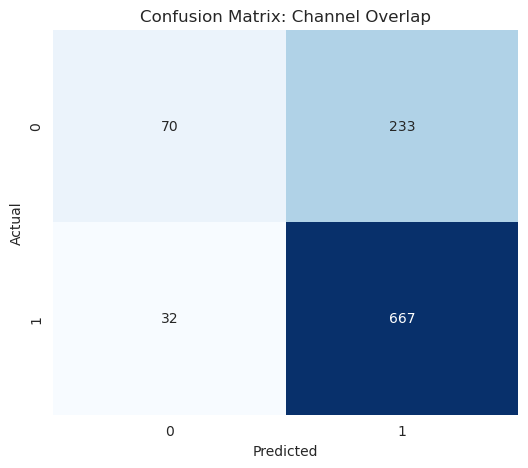

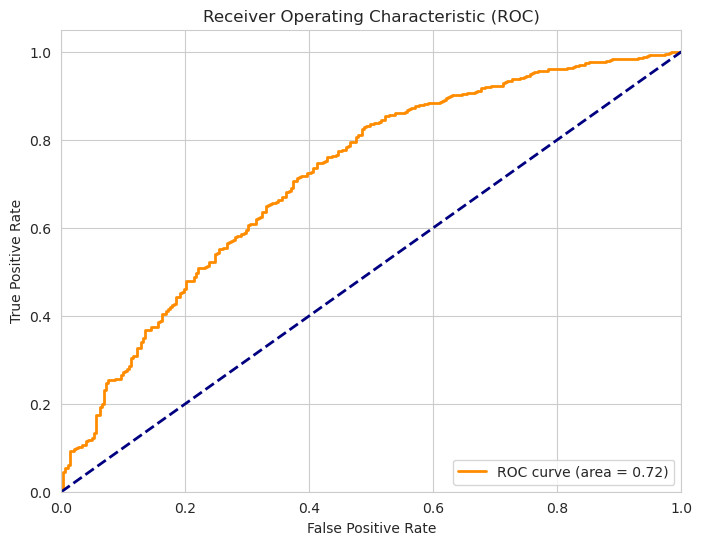

In [ ]:
print("Classification Report:")
print(classification_report(targets_overlap, preds_overlap_binary))

# ROC-AUC Score
roc_auc = roc_auc_score(targets_overlap, probs_overlap)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(targets_overlap, preds_overlap_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Channel Overlap")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(targets_overlap, probs_overlap)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Conclusion (Classification)
The classification results showed a ~70% accuracy for the identification of spectral overlapping, this result is similar to a pending for publication congress paper
that used histograms with these same symbols and extracted a similar set of features as us, however, in their case, they used a discrete histogram, with a determined number of bins,
and as such, our approach should be a more precise version of theirs.

The ROC-AUC curve can also show valuable results, because we see the behaviour of the predictions without being affected by class imbalance, and as such, we actually see an
increase in the resulting metric of about 2 pp.

### 5.2 Regression Results (OSNR)

For the regression results we assess the accuracy of the OSNR estimation task by calculating error metrics and visualizing the correlation between predicted and actual values.

**Key Steps**
* **Error Metrics:** Computes the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to quantify the average deviation in dB.
* **Scatter Plot:** Visualizes the relationship between Ground Truth and Predicted OSNR.
A red dashed line ($y=x$) is plotted to indicate perfect prediction.

OSNR MAE:  2.4970 dB
OSNR RMSE: 3.0290 dB


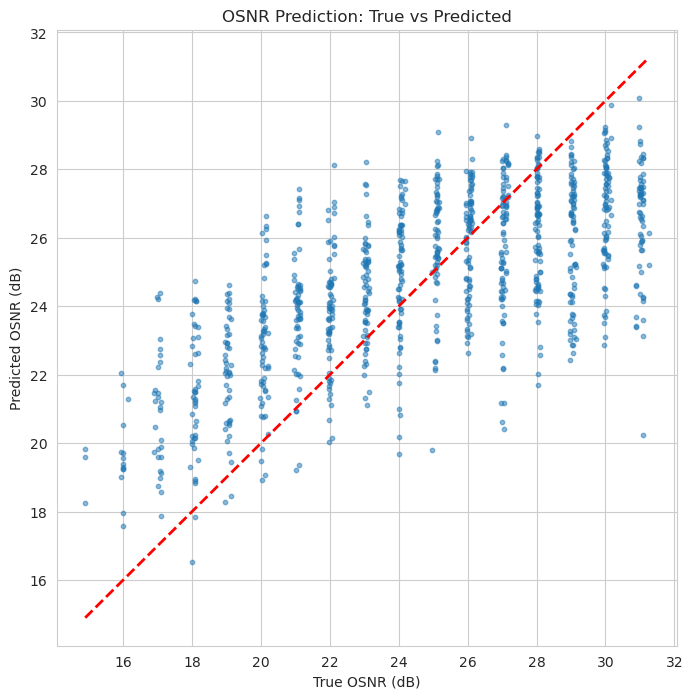

In [ ]:
mae = mean_absolute_error(targets_osnr, preds_osnr)
rmse = np.sqrt(mean_squared_error(targets_osnr, preds_osnr))

print(f"OSNR MAE:  {mae:.4f} dB")
print(f"OSNR RMSE: {rmse:.4f} dB")

# Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(targets_osnr, preds_osnr, alpha=0.5, s=10)
plt.plot(
    [min(targets_osnr), max(targets_osnr)],
    [min(targets_osnr), max(targets_osnr)],
    "r--",
    lw=2,
)
plt.xlabel("True OSNR (dB)")
plt.ylabel("Predicted OSNR (dB)")
plt.title("OSNR Prediction: True vs Predicted")
plt.grid(True)
plt.show()

### Conclusion (Regression)
In this case, the results showed a really deviated regression, where the ground truth and the prediction were off significantly from each other for almost every prediction, however,
if we compare this result with the reference paper that's pending for publication, we can actually see a similar result, both in the MAE and RMSE values, making them comparable as
alternative solutions.

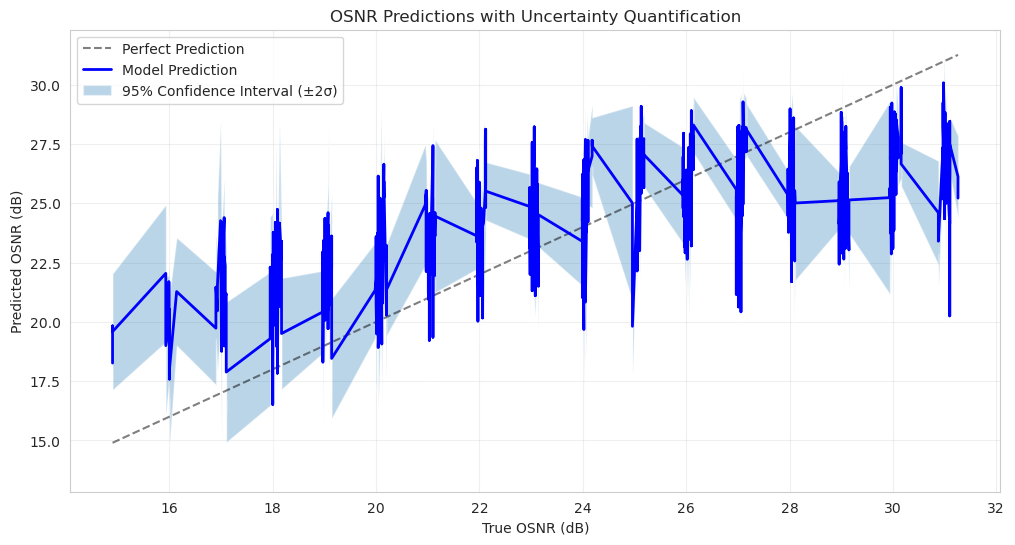

In [ ]:
# 1. Prediction Interval Plot
sort_idx = np.argsort(targets_osnr)
targets_sorted = targets_osnr[sort_idx]
preds_sorted = preds_osnr[sort_idx]
std_sorted = std_osnr[sort_idx]

plt.figure(figsize=(12, 6))
plt.plot(targets_sorted, targets_sorted, "k--", label="Perfect Prediction", alpha=0.5)
plt.plot(targets_sorted, preds_sorted, "b-", label="Model Prediction", linewidth=2)
plt.fill_between(
    targets_sorted,
    preds_sorted - 2 * std_sorted,
    preds_sorted + 2 * std_sorted,
    alpha=0.3,
    label="95% Confidence Interval (±2σ)",
)
plt.xlabel("True OSNR (dB)")
plt.ylabel("Predicted OSNR (dB)")
plt.title("OSNR Predictions with Uncertainty Quantification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis: Prediction Interval
For the uncertainty quantification results of this regression task we see really uncertain ranges where no OSNR measurements existed, this is expected for a GP, as no training
samples in that area is modeled as a great uncertainty for a prediction in those values. Overall the model is sometimes not very sure about the values that it tries to predict,
this is good, as the model is not hallucinating by being sure about an error, but also represents a scarce of modelling that surely represents the phenomena that we're trying to
model in this work.

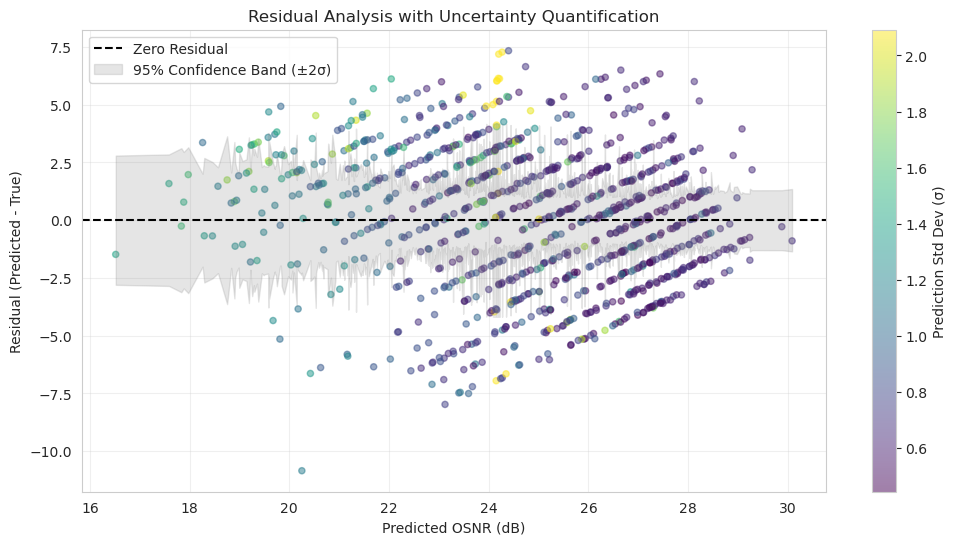

In [ ]:
# 2. Residual Analysis with Uncertainty
residuals = preds_osnr - targets_osnr

plt.figure(figsize=(12, 6))
plt.scatter(preds_osnr, residuals, alpha=0.5, s=20, c=std_osnr, cmap="viridis")
plt.axhline(y=0, color="k", linestyle="--", label="Zero Residual")

# Add ±2σ bounds sorted by prediction
sort_pred_idx = np.argsort(preds_osnr)
preds_in_order = preds_osnr[sort_pred_idx]
std_in_order = std_osnr[sort_pred_idx]

plt.fill_between(
    preds_in_order,
    -2 * std_in_order,
    2 * std_in_order,
    alpha=0.2,
    color="gray",
    label="95% Confidence Band (±2σ)",
)

plt.xlabel("Predicted OSNR (dB)")
plt.ylabel("Residual (Predicted - True)")
plt.title("Residual Analysis with Uncertainty Quantification")
plt.colorbar(label="Prediction Std Dev (σ)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis: Residuals
In this plot we can see the residual between the predicted value and the true value, there's a great amount of values that go outside the confidence band, according to the model,
these could be treated as outliers, because their feature do not correspond to the target value, but of course, this is not a database issue, is just an information scarcity or
ambiguous feature set.

95% Confidence Interval Coverage: 36.33%
(Should be close to 95% if uncertainty is well-calibrated)


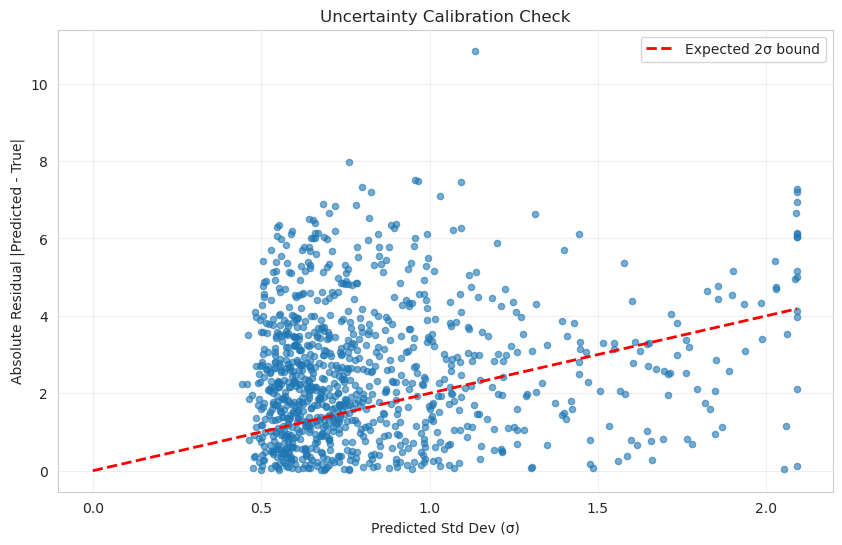

In [ ]:
# 3. Calibration Check
lower_bound = preds_osnr - 2 * std_osnr
upper_bound = preds_osnr + 2 * std_osnr

coverage = np.mean((targets_osnr >= lower_bound) & (targets_osnr <= upper_bound))
print(f"95% Confidence Interval Coverage: {coverage * 100:.2f}%")
print(f"(Should be close to 95% if uncertainty is well-calibrated)")

plt.figure(figsize=(10, 6))
plt.scatter(std_osnr, np.abs(residuals), alpha=0.6, s=20)
plt.plot(
    [0, np.max(std_osnr)],
    [0, np.max(std_osnr) * 2],
    "r--",
    label="Expected 2σ bound",
    linewidth=2,
)
plt.xlabel("Predicted Std Dev (σ)")
plt.ylabel("Absolute Residual |Predicted - True|")
plt.title("Uncertainty Calibration Check")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis: Calibration
These results show a confidence interval coverage of 36.33%, if most of the data rested in the confidence zone, we should be seeing a coverage around 95%, however we're
having an extremely low coverage of this metric, this represents a high uncertainty for our model, telling us that it is not sure about what's predicting based on the feature set
that is using.

## Final Project Conclusion
We have successfully implemented and evaluated a Multi-Output Gaussian Process for optical signal monitoring.
**Summary of Findings:**
1.  **Topology Extraction**: The removal of peak counts as features (due to constancy) simplified our input vector to 16 dimensions without loss of information.
2.  **LMC Architecture**: The shared latent functions allowed joint modeling, though the regression task (OSNR) remains challenging with high uncertainty.
3.  **Uncertainty**: The model honestly reports high uncertainty (low calibration coverage), which is preferable to over-confident errors in safety-critical optical networks.
